#### Name: Shashank Goel
#### Batch: B.Tech Data Science
#### Roll no: J011
#### Subject: NNDL

### CNN Visualization at any possible layers

when we do backprop instead of changing the weights, what if we change the image.

By doing this, we get dL/dw3 -> dw3/w2 -> dw2/dw1 -> dw1/x    = dL/dx

From here on. we move the image as:

Image -> Network (Frozen) -> Loss -> dL/dx -> Image.

So the weights are fixed and the images moves.

By doing this we can get, an image generated and see what the model sees (generalized form) of any class at any level.

- Saliency- Shows the image in a different color spectrum to highlight the most important regions.
- Grad-CAM- Uses the gradients of any target concept, flowing into the final convolutional layer to produce a coarse localization map highlighting the important regions in the image for predicting the concept.
- Guided backprop- Keeps only the evidence in favour of the target class. Better than Saliency and Grad-CAM. Gradient Ascent is another name for this. It is a technique to visualize the features learned by the network by maximizing the activation of a particular neuron or layer with respect to the input image.

Used in style transfer, feature visualization, and understanding model behavior.

### Deep Dream

Deep Dream is a computer vision program created by Google which uses a convolutional neural network to find and enhance patterns in images via algorithmic pareidolia, thus creating a dream-like hallucinogenic appearance in the deliberately over-processed images.

Deep Dream doesn't minimize the loss function, but instead maximizes the activation of certain layers in the network. This is done by performing gradient ascent on the input image to enhance features that the network has learned to recognize.

Going deep in the layer would create better image generation. The deeper the layer, the more abstract the features that are enhanced. For example, in the early layers of a CNN, the network may learn to recognize simple features such as edges and textures, while in the deeper layers, it may learn to recognize more complex features such as shapes and objects.

### Adversial Attacks

This technique solved a problem of 'Adversarial Attacks'. Adversarial attacks are a type of attack on machine learning models where an attacker intentionally perturbs the input data in a way that causes the model to make incorrect predictions. These perturbations are often imperceptible to humans, but they can cause the model to misclassify the input data.

### Two special applications of this visualization technique are:

### 1. Face Recognition- 

Using this we can generate a face of any person by giving the name of the person. The model will generate a face of that person by using the features learned by the model. 

For a model, same person can be identified in this process:

Photo on file -> SAME NETWORK (Frozen) ->  numbers -> Distance between them (Small distance means same person, large distance means different person)

Photo on the door -> SAME NETWORK (Frozen) ->  numbers -> Distance between them (Small distance means same person, large distance means different person)

Any metric can be used for similarity. For example, Euclidean distance, Cosine similarity, etc. The model will generate a face of that person by using the features learned by the model.

----- 

How to train such a model:

**Triplet Loss**-  This loss function is used to train the model to learn a feature space where images of the same person are closer together and images of different people are farther apart. 

The triplet loss function takes three inputs: an anchor image, a positive image (of the same person as the anchor), and a negative image (of a different person). The loss function encourages the model to minimize the distance between the anchor and positive images while maximizing the distance between the anchor and negative images.

This mitigates the problem of False Positives and False Negatives.

|| f(A) - f(P) ||^2 + alpha < || f(A) - f(N) ||^2

Where f(A) is the feature vector of the anchor image, f(P) is the feature vector of the positive image, f(N) is the feature vector of the negative image, and alpha is a margin that defines how far apart the positive and negative images should be.

-----

### 2. Neural Style Transfer-  

Using this we can transfer the style of one image to another image. For example, we can transfer the style of a painting to a photograph. This is done by using the features learned by the model to generate a new image that combines the content of the photograph with the style of the painting.

So the cost function is a weighted sum of the content loss and the style loss. The content loss measures how much the generated image differs from the content image, while the style loss measures how much the generated image differs from the style image.


J(G) = alpha * J_content(C,G) + beta * J_style(S,G)

Where J(G) is the total loss, J_content(C,G) is the content loss, J_style(S,G) is the style loss, and alpha and beta are weights that control the relative importance of the content and style losses. 

Increasing alpha will make the generated image more similar to the content image, while increasing beta will make the generated image more similar to the style image. By adjusting these weights, we can control the balance between content and style in the generated image.

Architecture:

Content Image + Style Image -> Sample Image (Starts at none) -> SAME NETWORK (Frozen) -> Content Loss + Style Loss -> dL/dx -> Sample Image

### Imports

In [ ]:
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.models import resnet18, ResNet18_Weights

In [2]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [3]:
class_names = weights.meta["categories"]
print(f'Number of classes: {len(class_names)}')

Number of classes: 1000


In [4]:
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

# Reshape both to (batch, channels, height, width) for broadcasting
mean = mean.view(1, 3, 1, 1)
std = std.view(1, 3, 1, 1)

In [5]:
with h5py.File(("./data/train_catvnoncat.h5"), "r") as f:

    all_images = f["train_set_x"][:]

Shape of the first image: (64, 64, 3)


Text(0.5, 1.0, 'Cat')

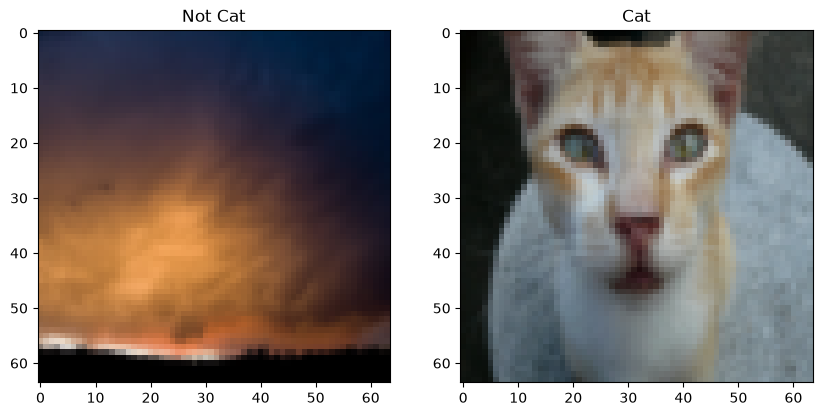

In [6]:
print(f"Shape of the first image: {all_images[0].shape}")
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(all_images[0])
plt.title("Not Cat")
plt.subplot(1, 2, 2)
plt.imshow(all_images[11])
plt.title("Cat")

In [8]:
raw = all_images[11]/255.0
print(f"Shape of the image: {raw.shape}")
image = torch.tensor(raw).float()
print(f"Shape of the image tensor: {image.shape}")
image = image.permute(2, 0, 1).unsqueeze(0)  # Change shape to (1, 3, H, W)
print(f"Shape of the image tensor after permute and unsqueeze: {image.shape}")
image = F.interpolate(image, size=(224, 224), mode='bilinear', align_corners=False)
print(f"Shape of the image tensor after interpolation: {image.shape}")
normalized_image = (image - mean) / std
print(f"Shape of the normalized image tensor: {normalized_image.shape}")

Shape of the image: (64, 64, 3)
Shape of the image tensor: torch.Size([64, 64, 3])
Shape of the image tensor after permute and unsqueeze: torch.Size([1, 3, 64, 64])
Shape of the image tensor after interpolation: torch.Size([1, 3, 224, 224])
Shape of the normalized image tensor: torch.Size([1, 3, 224, 224])


In [ ]:
with torch.no_grad():
    scores = model(normalized_image)
    #print(scores)

prob = scores.softmax(dim=1)
print(f'Shape of prob: {prob.shape}')

conf = float(prob.max())
label = class_names[prob.argmax()]
print(f'Predicted label: {label}, Confidence: {conf:.4f}')

Shape of prob: torch.Size([1, 1000])
Predicted label: Egyptian cat, Confidence: 0.8342


In [ ]:
def grad_of_img(): 
    x = normalized_image.clone()
    x.requires_grad_(True)
    score = model(x)[0, prob.argmax()]
    
    model.zero_grad()
    score.backward()
    gradient = x.grad[0]
    return gradient

grad = grad_of_img()

# Saliency

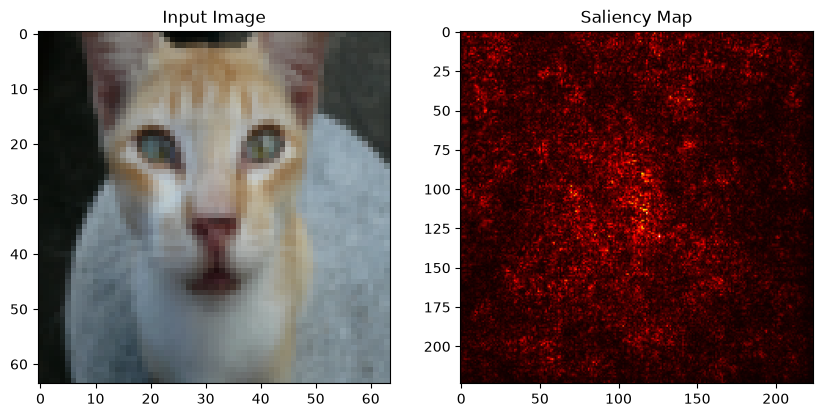

In [18]:
size_grad = grad.abs()
saliency = size_grad.max(dim=0).values

# Plot the saliency map, input and saliency
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(raw)
plt.title("Input Image")
plt.subplot(1, 2, 2)
plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map")
plt.show()


# Guided Backprop

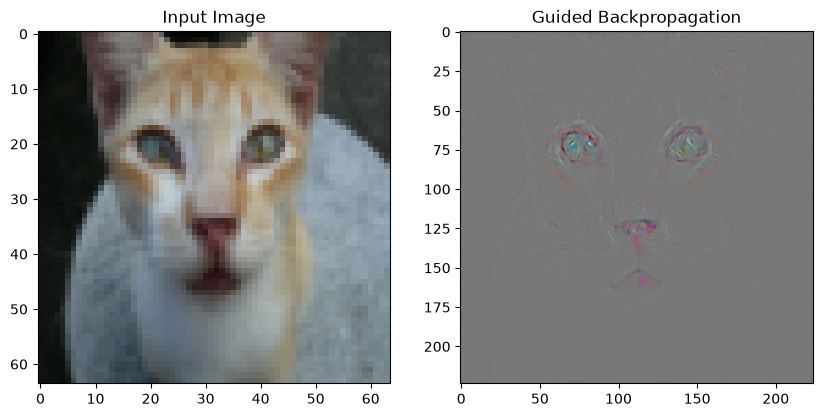

In [19]:
for layer in model.modules():
    if isinstance(layer, torch.nn.ReLU):
        layer.inplace = False

handles = []
for layer in model.modules():
    if isinstance(layer, torch.nn.ReLU):
        handle = layer.register_backward_hook(lambda module, grad_in, grad_out: (torch.clamp(grad_in[0], min=0.0),))
        handles.append(handle)

guided_grad = grad_of_img()

for handle in handles:
    handle.remove()

guided_picture = guided_grad - guided_grad.min()
guided_picture /= guided_picture.max()
guided_picture = guided_picture.permute(1, 2, 0).detach().numpy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(raw)
plt.title("Input Image")
plt.subplot(1, 2, 2)
plt.imshow(guided_picture)
plt.title("Guided Backpropagation")
plt.show()


# Other Images

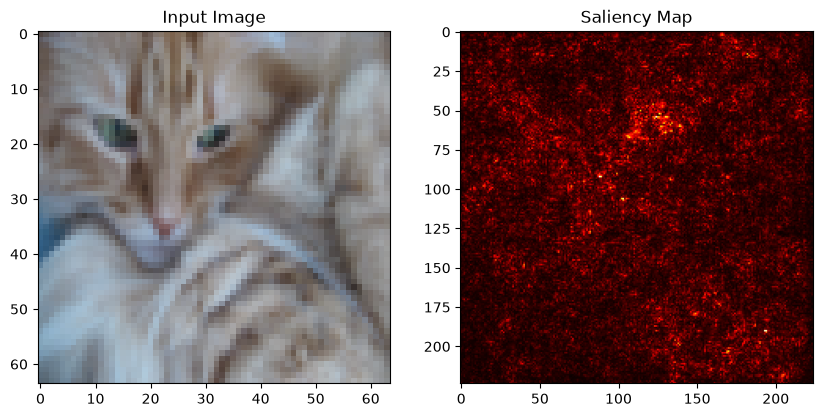

In [20]:
raw = all_images[2]/255.0
image = torch.tensor(raw).float()
image = image.permute(2, 0, 1).unsqueeze(0)  # Change shape to (1, 3, H, W)
image = F.interpolate(image, size=(224, 224), mode='bilinear', align_corners=False)
normalized_image = (image - mean) / std

grad = grad_of_img()
size_grad = grad.abs()
saliency = size_grad.max(dim=0).values

# Plot the saliency map, input and saliency
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(raw)
plt.title("Input Image")
plt.subplot(1, 2, 2)
plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map")
plt.show()


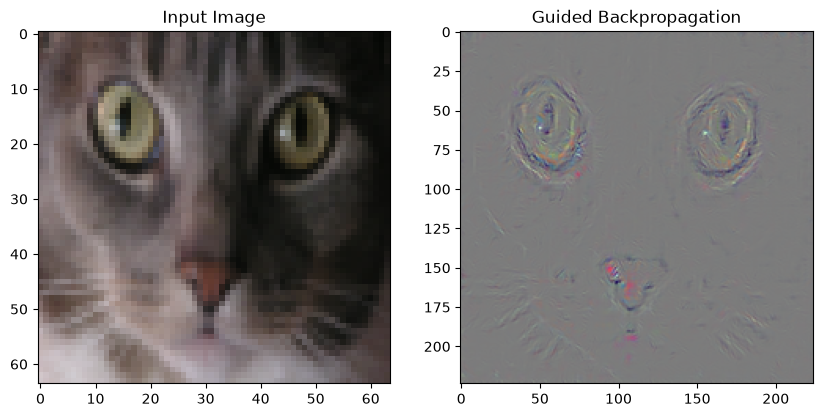

In [22]:
raw = all_images[60]/255.0
image = torch.tensor(raw).float()
image = image.permute(2, 0, 1).unsqueeze(0)  # Change shape to (1, 3, H, W)
image = F.interpolate(image, size=(224, 224), mode='bilinear', align_corners=False)
normalized_image = (image - mean) / std

for layer in model.modules():
    if isinstance(layer, torch.nn.ReLU):
        layer.inplace = False

handles = []
for layer in model.modules():
    if isinstance(layer, torch.nn.ReLU):
        handle = layer.register_backward_hook(lambda module, grad_in, grad_out: (torch.clamp(grad_in[0], min=0.0),))
        handles.append(handle)

guided_grad = grad_of_img()

for handle in handles:
    handle.remove()

guided_picture = guided_grad - guided_grad.min()
guided_picture /= guided_picture.max()
guided_picture = guided_picture.permute(1, 2, 0).detach().numpy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(raw)
plt.title("Input Image")
plt.subplot(1, 2, 2)
plt.imshow(guided_picture)
plt.title("Guided Backpropagation")
plt.show()


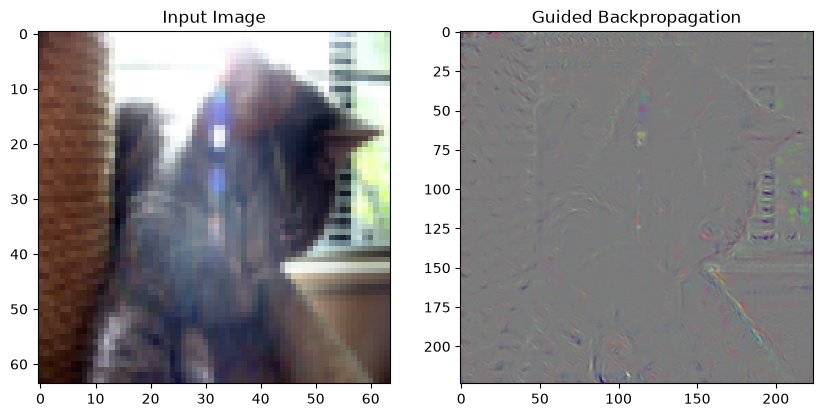

In [30]:
raw = all_images[42]/255.0
image = torch.tensor(raw).float()
image = image.permute(2, 0, 1).unsqueeze(0)  # Change shape to (1, 3, H, W)
image = F.interpolate(image, size=(224, 224), mode='bilinear', align_corners=False)
normalized_image = (image - mean) / std

for layer in model.modules():
    if isinstance(layer, torch.nn.ReLU):
        layer.inplace = False

handles = []
for layer in model.modules():
    if isinstance(layer, torch.nn.ReLU):
        handle = layer.register_backward_hook(lambda module, grad_in, grad_out: (torch.clamp(grad_in[0], min=0.0),))
        handles.append(handle)

guided_grad = grad_of_img()

for handle in handles:
    handle.remove()

guided_picture = guided_grad - guided_grad.min()
guided_picture /= guided_picture.max()
guided_picture = guided_picture.permute(1, 2, 0).detach().numpy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(raw)
plt.title("Input Image")
plt.subplot(1, 2, 2)
plt.imshow(guided_picture)
plt.title("Guided Backpropagation")
plt.show()